In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import random
import glob
import os
import io

In [2]:
def get_train_df(data_path, train_filenames, name):
    train_files = glob.glob(os.path.join(data_path, train_filenames))
    df_train = pd.concat([pd.read_parquet(f) for f in train_files], ignore_index=True)
    df_train['hospital'] = name
    return df_train

In [3]:
def get_random_x_rays(hospitals, size):
    x_rays_dict = {}
    for hospital in hospitals:
        random_indices = random.sample(hospital.index.tolist(), size)
        imgs_dict = hospital['image'].loc[random_indices].tolist()
        labels = hospital['label'].loc[random_indices].tolist()
        x_rays_dict[hospital['hospital'].unique()[0]] = (imgs_dict, labels)

    return x_rays_dict

In [4]:
def plot_x_rays(x_rays_dict, size):
    nrows = len(x_rays_dict) # Just 3 hospitals
    ncols = size # Num. of X-Rays per hospital
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4))
    for i, key in enumerate(x_rays_dict):
        images_dict, labels = x_rays_dict[key]
        for j, (img_bytes, label) in enumerate(zip(images_dict, labels)):
            img = Image.open(io.BytesIO(img_bytes['bytes']))
            ax[i, j].imshow(img, cmap='gray')
            ax[i, j].set_xlabel(label, fontsize=15)
            ax[i, j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax[i, ncols // 2].set_title(key, fontsize=20)
    plt.tight_layout()
    plt.show()

In [5]:
data_dir_a = '../../data/hospital_a/'
data_dir_b = '../../data/hospital_b/'
data_dir_c = '../../data/hospital_c/'
train_filenames = 'train-*.parquet'

df_train_a = get_train_df(data_dir_a, train_filenames, 'Hospital A')
df_train_b = get_train_df(data_dir_b, train_filenames, 'Hospital B')
df_train_c = get_train_df(data_dir_c, train_filenames, 'Hospital C')

# Visualization 

In [6]:
hospitals = [df_train_a, df_train_b, df_train_c]
size = 5 # images per hospital
x_rays_dict = get_random_x_rays(hospitals, size)

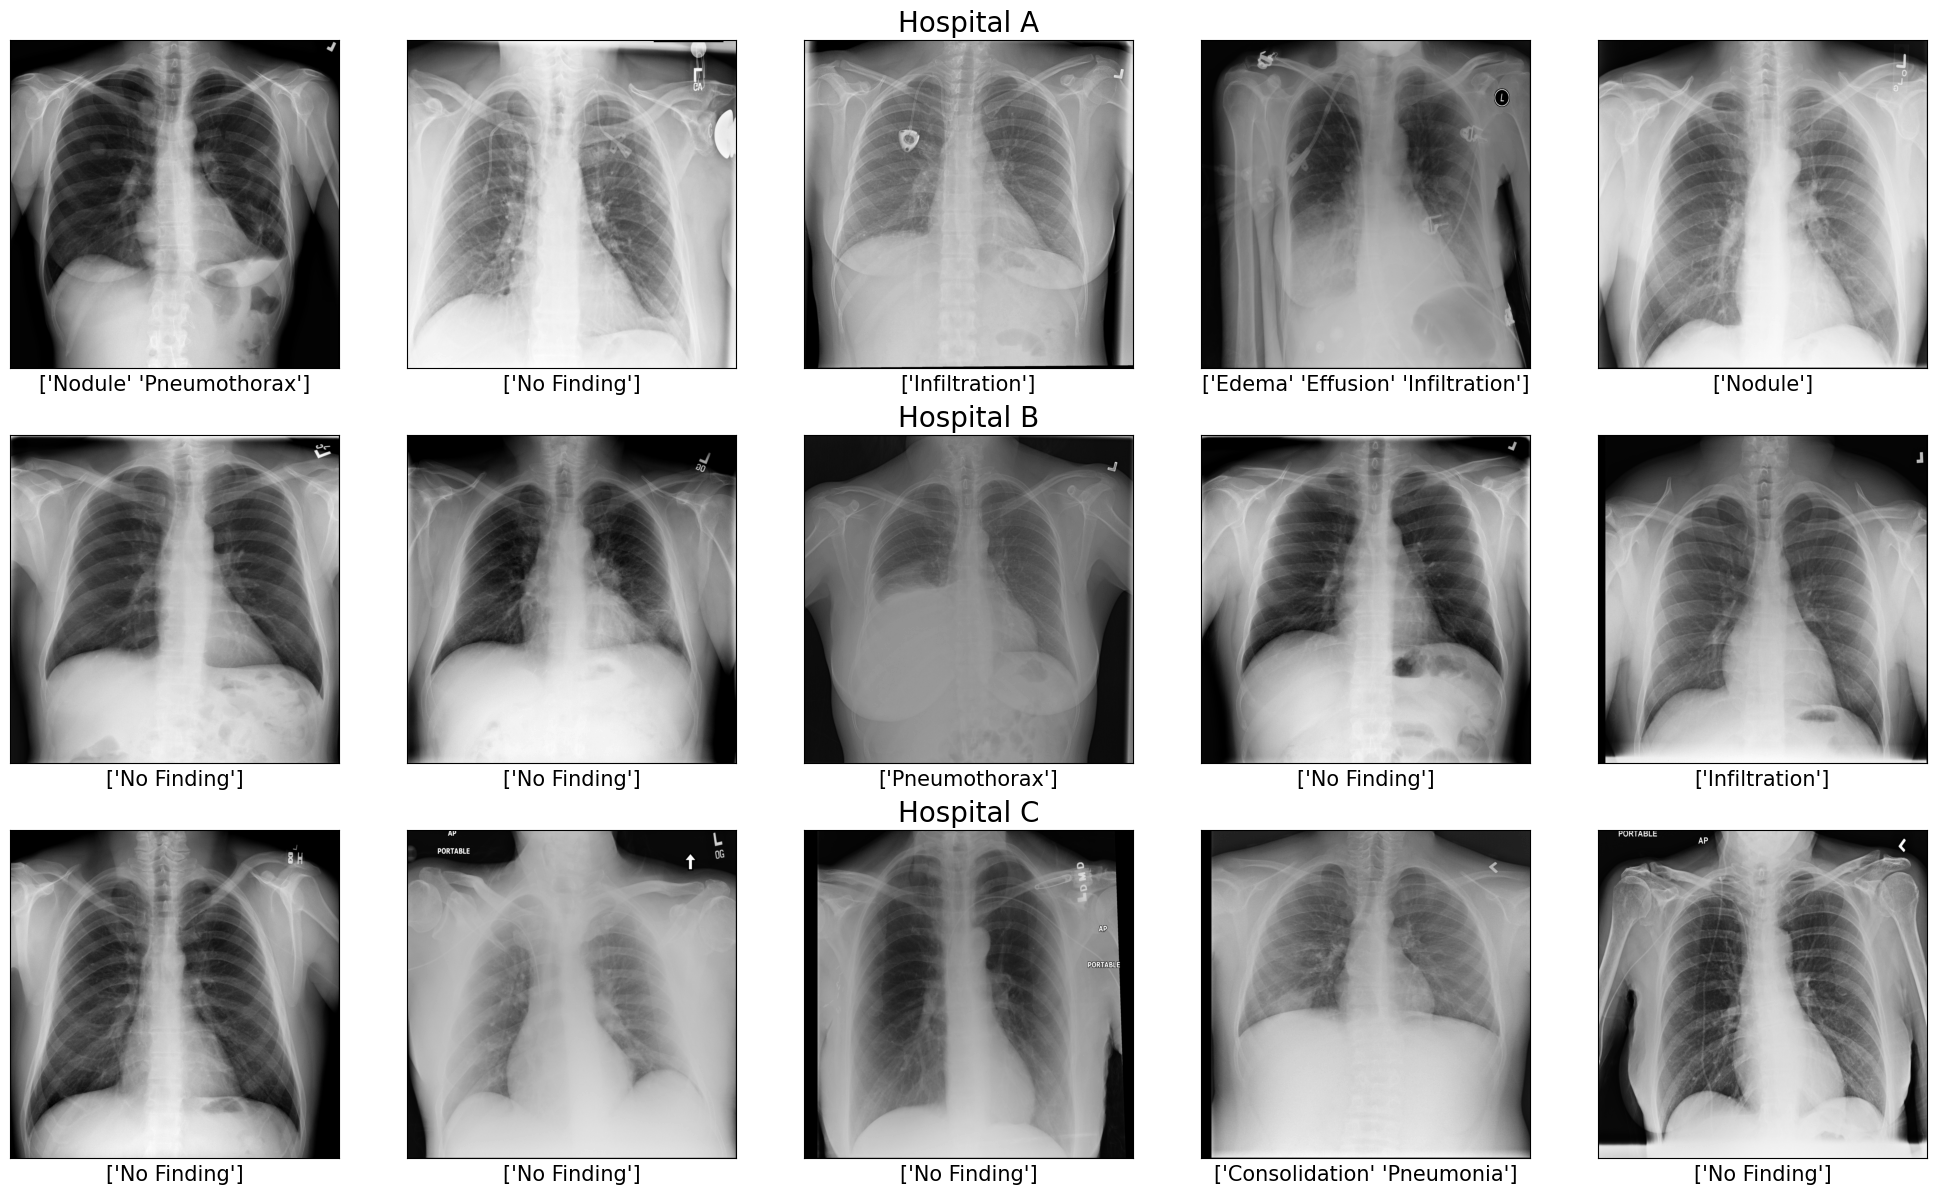

In [7]:
plot_x_rays(x_rays_dict, size)